# Phase 4 — VAR (Vector AutoRegression) Model

| | |
|---|---|
| **Dataset** | `data/processed/india_macro_quarterly.csv` |
| **Model** | VAR(p) on first-differenced I(1) series |
| **Indicators** | Repo Rate, CPI Inflation, GDP Growth, Unemployment Rate |
| **Lag selection** | `select_order(maxlags=8)` — AIC / BIC |

**Two scenarios** are compared throughout:
- **Scenario A** — 3 core variables, full sample 2010-Q2 to 2025-Q4 (63 quarters). Used for forecast metrics.
- **Scenario B** — 4 variables including Repo Rate, sample capped at 2021-Q1 (43 quarters). Used for Granger / IRF / policy analysis.


## § 0 — Setup

In [1]:
import sys, warnings, json, pickle
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings("ignore")
if hasattr(sys.stdout, "reconfigure"): sys.stdout.reconfigure(encoding="utf-8")

ROOT     = Path("..").resolve()
SRC_DIR  = ROOT / "src"
DOCS_DIR = ROOT / "docs"
MDL_DIR  = ROOT / "models"
MDL_DIR.mkdir(exist_ok=True)
DOCS_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(SRC_DIR))

# Dark plot theme
BG     = "#0f1117"
GRID   = "#2a2d3a"
TEXT   = "#e0e0e0"
COLORS = ["#7eb8f7", "#a8e6cf", "#ff9f7f", "#c3a6ff", "#ffd580"]
plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG,
    "axes.edgecolor": GRID, "axes.labelcolor": TEXT,
    "axes.titlecolor": TEXT, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": TEXT, "ytick.color": TEXT,
    "text.color": TEXT, "legend.facecolor": "#1A1D27",
    "legend.edgecolor": GRID, "font.size": 11,
})

from model_var import (
    build_stationary_df, select_lag_order, fit_var,
    granger_causality_analysis, plot_irf,
    simulate_policy_shock, bootstrap_forecast_intervals,
)
print("model_var imported successfully.")


model_var imported successfully.


## § 1 — Data Preparation

All five macro indicators are **I(1)** (see Phase 2 ADF results). We apply
first-differencing before fitting the VAR.  Two sample windows are used:

| Scenario | Variables | Sample | N (after diff) |
|----------|-----------|--------|----------------|
| A | CPI, GDP, Unemployment | 2010-Q2 to 2025-Q4 | 63 |
| B | Repo Rate + above | 2010-Q2 to 2021-Q1 | 43 |


In [2]:
df_a = build_stationary_df(include_repo_rate=False, include_iip=False)
df_b = build_stationary_df(include_repo_rate=True,  include_iip=False)

print("Scenario A shape:", df_a.shape, "| first/last:", df_a.index[0].date(), "->", df_a.index[-1].date())
print("Scenario B shape:", df_b.shape, "| first/last:", df_b.index[0].date(), "->", df_b.index[-1].date())
print()
display(df_a.tail(6).round(4))


[build_stationary_df] Columns   : ['d_CPI_Inflation', 'd_GDP_Growth', 'd_Unemployment_Rate']
[build_stationary_df] Sample     : 2010-04-01 -> 2025-10-01 (63 quarters)
[build_stationary_df] Columns   : ['d_Repo_Rate', 'd_CPI_Inflation', 'd_GDP_Growth', 'd_Unemployment_Rate']
[build_stationary_df] Sample     : 2010-04-01 -> 2021-01-01 (44 quarters)
Scenario A shape: (63, 3) | first/last: 2010-04-01 -> 2025-10-01
Scenario B shape: (44, 4) | first/last: 2010-04-01 -> 2021-01-01



,d_CPI_Inflation,d_GDP_Growth,d_Unemployment_Rate
2024-07-01,0.0000,0.0000,0.000
2024-10-01,0.0000,0.0000,0.000
2025-01-01,-2.5542,0.4674,0.046
2025-04-01,0.0000,0.0000,0.000
2025-07-01,0.0000,0.0000,0.000
2025-10-01,0.0000,0.0000,0.000


## § 2 — Lag Order Selection

`select_order(maxlags=8)` fits VAR(1) through VAR(8) and computes four
information criteria:

| Criterion | Penalty | Preference |
|-----------|---------|------------|
| **AIC** | 2k | Richer models; better for forecasting |
| **BIC** | k ln(n) | Heavier penalty; preferred with n < 100 |
| **HQIC** | 2k ln(ln(n)) | Between AIC and BIC |
| **FPE** | Ratio of det(Sigma) | Similar to AIC in practice |

With ~43–63 usable quarters, **BIC** is the conservative, safer choice.


In [3]:
print("=== Scenario A (3 vars, full sample) ===")
lag_a = select_lag_order(df_a, maxlags=8)

print()
print("=== Scenario B (4 vars, Repo Rate included) ===")
lag_b = select_lag_order(df_b, maxlags=6)


=== Scenario A (3 vars, full sample) ===

  LAG ORDER SELECTION RESULTS
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0     -0.9954    -0.8859*      0.3696    -0.9530*
1     -0.6721     -0.2341      0.5110     -0.5027
2     -0.3493      0.4171      0.7081    -0.05293
3    -0.02718       1.068      0.9852      0.3962
4      -1.262      0.1618     0.2911*     -0.7112
5     -0.9511      0.8007      0.4069     -0.2737
6     -0.6463       1.434      0.5727      0.1582
7     -0.3505       2.058      0.8117      0.5810
8     -1.410*       1.327      0.3028     -0.3514
-------------------------------------------------

  AIC optimal lag : 8
  BIC optimal lag : 0
  FPE optimal lag : 4
  HQIC optimal lag: 0

  >> Selected lag order (BIC): 1

=== Scenario B (4 vars, Repo Rate included) ===

  LAG ORDER SELECTION RESULTS
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC    

## § 3 — VAR Fit & Model Summary

The fitted VAR(p) jointly models all k endogenous variables:

$$Y_t = c + A_1 Y_{t-1} + \cdots + A_p Y_{t-p} + u_t$$

where $Y_t$ is the vector of first-differenced macro indicators,
$A_i$ are $(k \times k)$ coefficient matrices, and $u_t \sim WN(0, \Sigma)$.

Each row of the summary is an OLS regression of one indicator on its own
lags and the lags of all other indicators.


In [4]:
result_a = fit_var(df_a, lag_a)
print()
result_b = fit_var(df_b, lag_b)



  FITTING VAR(1)
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 18, Aug, 2026
Time:                     00:31:42
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                  -0.269952
Nobs:                     62.0000    HQIC:                 -0.520010
Log likelihood:          -230.791    FPE:                   0.506051
AIC:                    -0.681655    Det(Omega_mle):        0.419506
--------------------------------------------------------------------
Results for equation d_CPI_Inflation
                            coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------------
const                         -0.165590         0.118333           -1.399           0.162
L1.d_CPI_Inflation            -0.035611         0.140356           -0.254           0.

## § 4 — Granger Causality Tests

**Granger causality**: X Granger-causes Y if past values of X improve
prediction of Y beyond what Y's own history provides.

- H₀: X does **not** Granger-cause Y
- p ≤ 0.05 → reject H₀ → X Granger-causes Y

This is a *predictive* relationship, not structural causality.


In [5]:
# Scenario A: does CPI Granger-cause GDP and Unemployment?
print("=== Scenario A: d_CPI_Inflation as cause ===")
gc_a = granger_causality_analysis(df_a, lag_a, caused_by="d_CPI_Inflation")

# Scenario B: does Repo Rate Granger-cause CPI / GDP / Unemployment?
print()
print("=== Scenario B: d_Repo_Rate as cause ===")
gc_b = granger_causality_analysis(df_b, lag_b, caused_by="d_Repo_Rate")


=== Scenario A: d_CPI_Inflation as cause ===

  GRANGER CAUSALITY: Does 'd_CPI_Inflation' Granger-cause each variable?
  H0: 'd_CPI_Inflation' does NOT Granger-cause the target
  Significance level: alpha = 0.05  |  Lag order: 1

  -- Target: d_GDP_Growth --
  F-test p-value : 0.9927
  Result         : NOT significant (p=0.9927 > 0.05)

  Plain English  : Past changes in CPI Inflation do NOT add
                   meaningful predictive power for future
                   GDP Growth movements once we already
                   account for GDP Growth's own history.
                   This could mean: (a) the transmission
                   lag is longer than 1 quarter(s),
                   (b) the relationship is non-linear, or
                   (c) there genuinely is no Granger-causal link.

  -- Target: d_Unemployment_Rate --
  F-test p-value : 0.8622
  Result         : NOT significant (p=0.8622 > 0.05)

  Plain English  : Past changes in CPI Inflation do NOT add
                   m

## § 5 — Impulse Response Function (10-quarter horizon)

The orthogonalised IRF uses Cholesky decomposition to isolate the effect of a
**one-unit shock to d_Repo_Rate** on all other variables, holding contemporaneous
shocks to the other variables to zero.

**Ordering** (Cholesky causal chain):
> d_Repo_Rate → d_CPI_Inflation → d_GDP_Growth → d_Unemployment_Rate

This embeds the assumption that monetary policy affects prices and output with
a lag, which is consistent with standard New Keynesian transmission mechanisms.


IRF plot saved -> C:\Users\arnav\Desktop\Projects\Economic Policy Impact Simulator\docs\var_irf_repo_rate.png


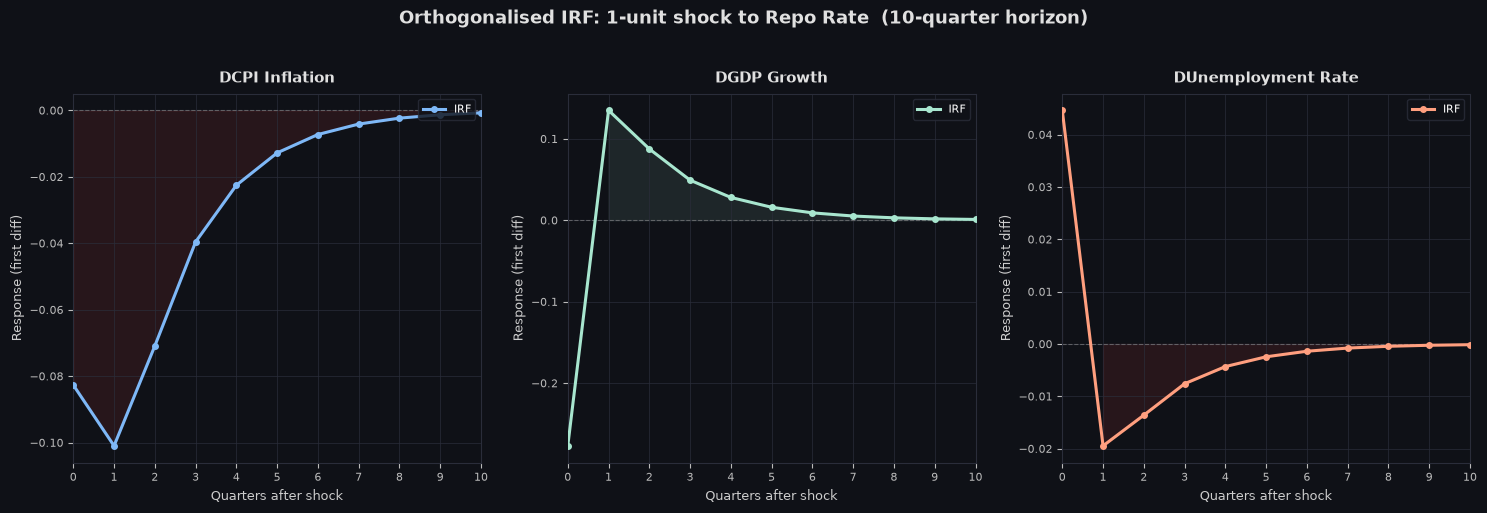


Orthogonalised IRF values (rows = quarters after shock):
      d_CPI_Inflation  d_GDP_Growth  d_Unemployment_Rate
Q+0         -0.082679     -0.277066             0.044632
Q+1         -0.100985      0.134917            -0.019470
Q+2         -0.070917      0.087508            -0.013608
Q+3         -0.039612      0.049167            -0.007604
Q+4         -0.022541      0.027964            -0.004327
Q+5         -0.012806      0.015887            -0.002458
Q+6         -0.007276      0.009027            -0.001397
Q+7         -0.004134      0.005129            -0.000794
Q+8         -0.002349      0.002914            -0.000451
Q+9         -0.001335      0.001656            -0.000256
Q+10        -0.000758      0.000941            -0.000146


In [6]:
irf = plot_irf(
    result_b,
    impulse_var="d_Repo_Rate",
    periods=10,
    orth=True,
    save_path=DOCS_DIR / "var_irf_repo_rate.png",
)


## § 6 — Forecast Evaluation (Train / Test Split)

We hold out the **last 10 quarters** (2.5 years) as the test set and fit
the VAR on the remaining training data.  The model then forecasts 10 steps
ahead from the end of training.

Metrics are computed on **first-differenced** values (what the VAR directly
predicts).  MAPE is excluded where the actual value passes through zero.


In [7]:
from statsmodels.tsa.api import VAR

N_TEST = 10

# ── Scenario A train/test ─────────────────────────────────────────────────
train_a = df_a.iloc[:-N_TEST]
test_a  = df_a.iloc[-N_TEST:]

model_a_tt = VAR(train_a)
res_a_tt   = model_a_tt.fit(lag_a)

# N_TEST-step ahead forecast seeded from last lag_a rows of training data
fc_a   = res_a_tt.forecast(train_a.values[-lag_a:], steps=N_TEST)
fc_df_a = pd.DataFrame(fc_a, columns=train_a.columns, index=test_a.index)

# Metrics
metrics_a = {}
print(f"Scenario A — Forecast Metrics (first-differenced values, last {N_TEST} quarters)")
print(f"{'Indicator':<28}  {'RMSE':>8}  {'MAPE':>10}")
print("-" * 52)
for col in train_a.columns:
    actual = test_a[col].values
    pred   = fc_df_a[col].values
    rmse   = float(np.sqrt(np.mean((actual - pred) ** 2)))
    # MAPE: skip quarters where actual is near zero
    mask   = np.abs(actual) > 0.01
    mape   = float(np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100) if mask.sum() else float("nan")
    metrics_a[col] = {"RMSE": round(rmse, 6), "MAPE": round(mape, 4) if not np.isnan(mape) else None}
    mape_str = f"{mape:.2f}%" if not np.isnan(mape) else "N/A"
    print(f"  {col:<26}  {rmse:>8.4f}  {mape_str:>10}")

# ── Scenario B train/test ─────────────────────────────────────────────────
print()
train_b = df_b.iloc[:-N_TEST]
test_b  = df_b.iloc[-N_TEST:]

model_b_tt = VAR(train_b)
res_b_tt   = model_b_tt.fit(lag_b)

fc_b    = res_b_tt.forecast(train_b.values[-lag_b:], steps=N_TEST)
fc_df_b = pd.DataFrame(fc_b, columns=train_b.columns, index=test_b.index)

metrics_b = {}
print(f"Scenario B — Forecast Metrics (first-differenced values, last {N_TEST} quarters)")
print(f"{'Indicator':<28}  {'RMSE':>8}  {'MAPE':>10}")
print("-" * 52)
for col in train_b.columns:
    actual = test_b[col].values
    pred   = fc_df_b[col].values
    rmse   = float(np.sqrt(np.mean((actual - pred) ** 2)))
    mask   = np.abs(actual) > 0.01
    mape   = float(np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100) if mask.sum() else float("nan")
    metrics_b[col] = {"RMSE": round(rmse, 6), "MAPE": round(mape, 4) if not np.isnan(mape) else None}
    mape_str = f"{mape:.2f}%" if not np.isnan(mape) else "N/A"
    print(f"  {col:<26}  {rmse:>8.4f}  {mape_str:>10}")


Scenario A — Forecast Metrics (first-differenced values, last 10 quarters)
Indicator                         RMSE        MAPE
----------------------------------------------------
  d_CPI_Inflation               0.7979      88.85%
  d_GDP_Growth                  0.1596      91.49%
  d_Unemployment_Rate           0.0729     244.61%

Scenario B — Forecast Metrics (first-differenced values, last 10 quarters)
Indicator                         RMSE        MAPE
----------------------------------------------------
  d_Repo_Rate                   0.2655     119.94%
  d_CPI_Inflation               1.0905      71.67%
  d_GDP_Growth                  5.8263      99.13%
  d_Unemployment_Rate           0.7289     100.01%


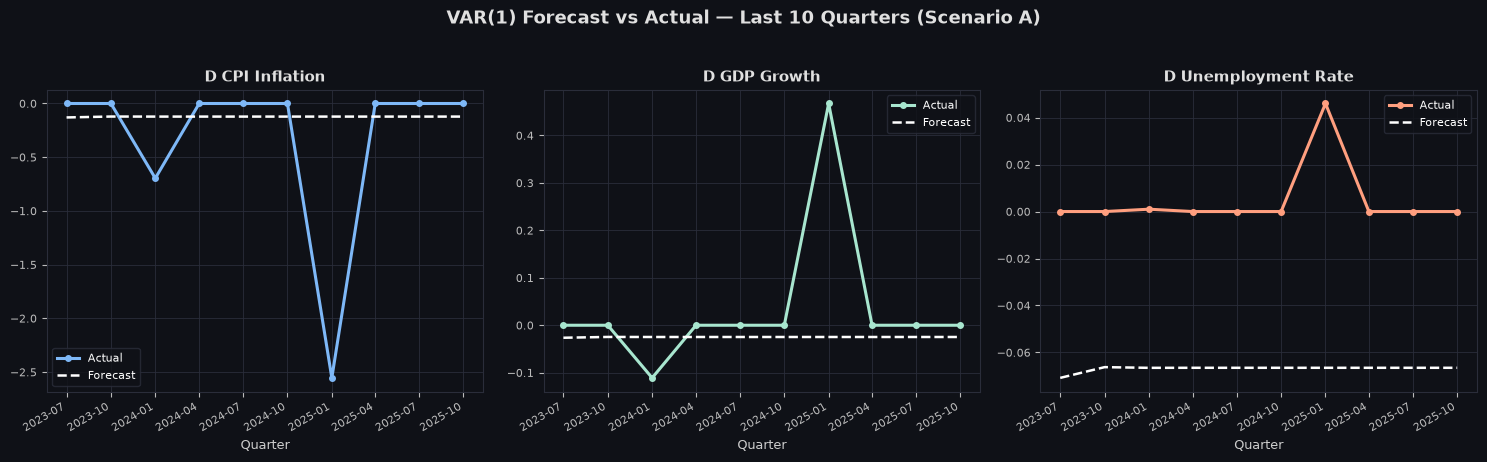

Saved docs/var_forecast_vs_actual.png


In [8]:
# Plot actual vs forecast for Scenario A (full-sample, 3 vars)
n_vars = len(train_a.columns)
fig, axes = plt.subplots(1, n_vars, figsize=(5 * n_vars, 4.5), squeeze=False)
fig.patch.set_facecolor(BG)
fig.suptitle(f"VAR({lag_a}) Forecast vs Actual — Last {N_TEST} Quarters (Scenario A)",
             fontsize=13, fontweight="bold", color=TEXT, y=1.02)

for ax_i, (col, color) in enumerate(zip(train_a.columns, COLORS)):
    ax = axes[0][ax_i]
    ax.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID)

    ax.plot(test_a.index, test_a[col].values, color=color, linewidth=2.2,
            label="Actual", marker="o", markersize=4, zorder=4)
    ax.plot(test_a.index, fc_df_a[col].values, color="white", linewidth=1.8,
            linestyle="--", label="Forecast", zorder=5)

    label = col.replace("d_", "D ").replace("_", " ")
    ax.set_title(label, fontsize=11, color=TEXT, fontweight="bold", pad=6)
    ax.set_xlabel("Quarter", color="#ccc", fontsize=9)
    ax.tick_params(colors="#bbb", labelsize=8)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
    ax.legend(fontsize=8, facecolor=BG, edgecolor=GRID, labelcolor="white")

plt.tight_layout()
fig.savefig(DOCS_DIR / "var_forecast_vs_actual.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()
print("Saved docs/var_forecast_vs_actual.png")


## § 7 — Bootstrap Forecast Intervals (90% CI)

Empirical 90% confidence bands constructed from 1000 residual-resampling
bootstrap replicates.  The fan chart shows three nested bands:
- **10–90th percentile** (outermost)
- **25–75th percentile** (interquartile range)
- **5–95th percentile** (the requested CI)

Why residual bootstrap over parametric intervals?  The COVID 2020 shock is
a 3σ outlier in the residual pool — parametric Gaussian bands would badly
understate the true downside tail risk.



  BOOTSTRAP FORECAST INTERVALS
  Replicates : 1000   |   CI level : 90%  (4th-95th percentile)
  Horizon    : 8 quarters from 2021-01-01
  Residuals  : 43 rows in pool

  Repo Rate:
     4th pct   Point  95th pct
Q+1  -0.7173 -0.2566    0.1454
Q+2  -0.6250 -0.1418    0.3735
Q+3  -0.6166 -0.0909    0.4199
Q+4  -0.5701 -0.0612    0.4519
Q+5  -0.5885 -0.0444    0.4543
Q+6  -0.5289 -0.0348    0.5248
Q+7  -0.5627 -0.0294    0.4957
Q+8  -0.5449 -0.0263    0.4794

  CPI Inflation:
     4th pct   Point  95th pct
Q+1  -3.4813 -0.6978    0.0924
Q+2  -1.7450 -0.0260    0.8318
Q+3  -1.8678 -0.1080    0.6764
Q+4  -1.9568 -0.1289    0.6627
Q+5  -2.6789 -0.1422    0.7177
Q+6  -2.8227 -0.1496    0.7549
Q+7  -1.9498 -0.1539    0.6734
Q+8  -2.7063 -0.1563    0.6840

  GDP Growth:
     4th pct   Point  95th pct
Q+1  -2.3378  0.2812    1.1280
Q+2  -2.5820 -0.1283    0.7781
Q+3  -2.5567 -0.0459    0.8458
Q+4  -2.7301 -0.0190    0.8276
Q+5  -2.8147 -0.0026    0.7755
Q+6  -2.8751  0.0066    0.9269
Q+7  -2.5


Fan chart saved -> C:\Users\arnav\Desktop\Projects\Economic Policy Impact Simulator\docs\var_bootstrap_fan.png


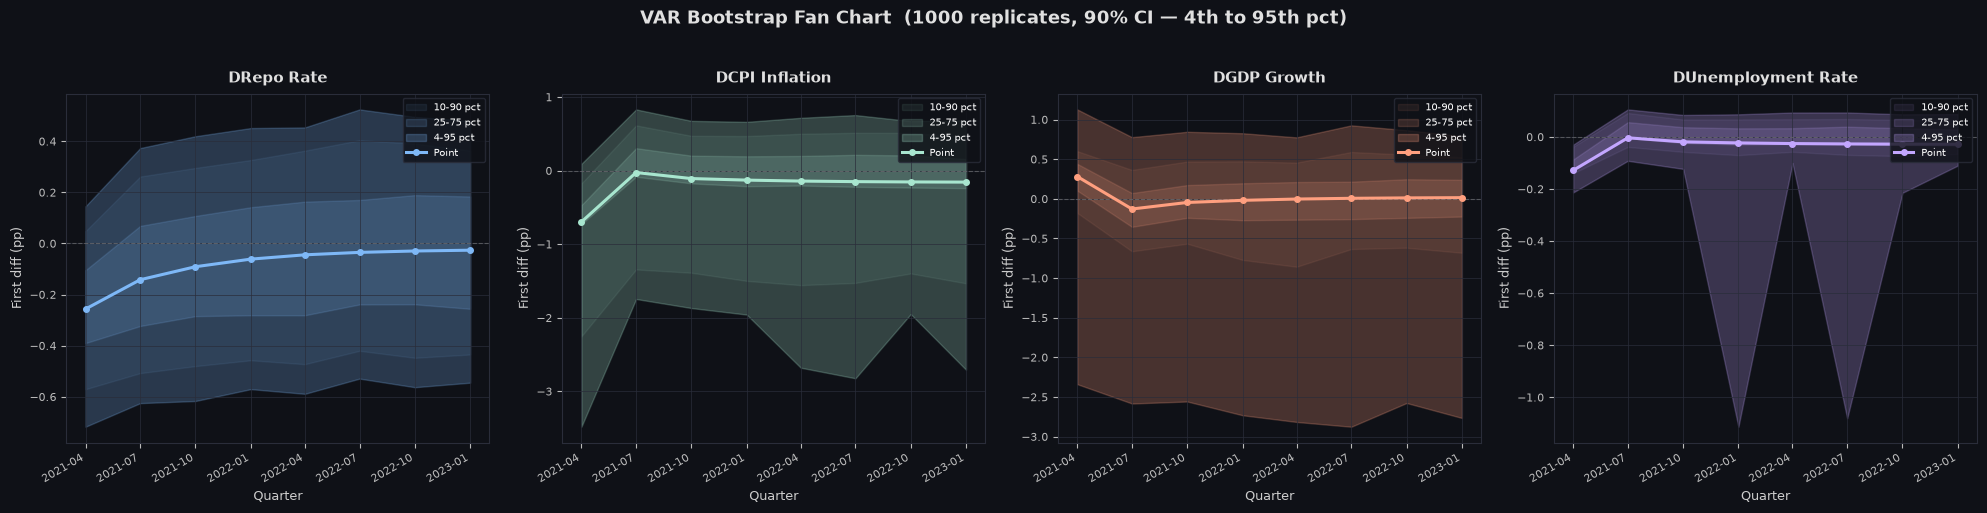

Bootstrap output shape: (8, 12)
Sample (d_CPI_Inflation):


,lower,point,upper
Quarter,,,
2021-04-01,-3.4813,-0.6978,0.0924
2021-07-01,-1.7450,-0.0260,0.8318
2021-10-01,-1.8678,-0.1080,0.6764
2022-01-01,-1.9568,-0.1289,0.6627
2022-04-01,-2.6789,-0.1422,0.7177
2022-07-01,-2.8227,-0.1496,0.7549
2022-10-01,-1.9498,-0.1539,0.6734
2023-01-01,-2.7063,-0.1563,0.6840


In [9]:
bdf = bootstrap_forecast_intervals(
    result_b,
    df_b,
    periods=8,
    n_boot=1000,
    ci=0.90,
    seed=42,
    save_path=DOCS_DIR / "var_bootstrap_fan.png",
)
print("Bootstrap output shape:", bdf.shape)
print("Sample (d_CPI_Inflation):")
display(bdf["d_CPI_Inflation"].round(4))


## § 8 — Policy Shock Simulation

Using `simulate_policy_shock()`, which scales the orthogonalised IRF by the
shock magnitude to project counterfactual level paths.

Two scenarios:
1. **+50 bps hike** — tightening monetary policy
2. **–25 bps cut** — easing monetary policy



  POLICY SIMULATION: +0.5 pp Repo Rate shock
  Horizon: 8 quarters from 2021-01-01

  Repo Rate:
                 Baseline      Shocked        Delta
Q+1                4.8934       4.9726       0.0792
Q+2                4.7515       4.8755       0.1240
Q+3                4.6606       4.8100       0.1494
Q+4                4.5994       4.7633       0.1639
Q+5                4.5550       4.7271       0.1721
Q+6                4.5202       4.6970       0.1768
Q+7                4.4908       4.6702       0.1794
Q+8                4.4645       4.6454       0.1810

  CPI Inflation:
                 Baseline      Shocked        Delta
Q+1                1.7011       1.6506      -0.0505
Q+2                1.6750       1.5891      -0.0860
Q+3                1.5671       1.4613      -0.1058
Q+4                1.4381       1.3211      -0.1170
Q+5                1.2960       1.1725      -0.1234
Q+6                1.1464       1.0193      -0.1271
Q+7                0.9925       0.8634      -0.1291



Policy shock plot saved -> C:\Users\arnav\Desktop\Projects\Economic Policy Impact Simulator\docs\var_shock_hike_50bps.png


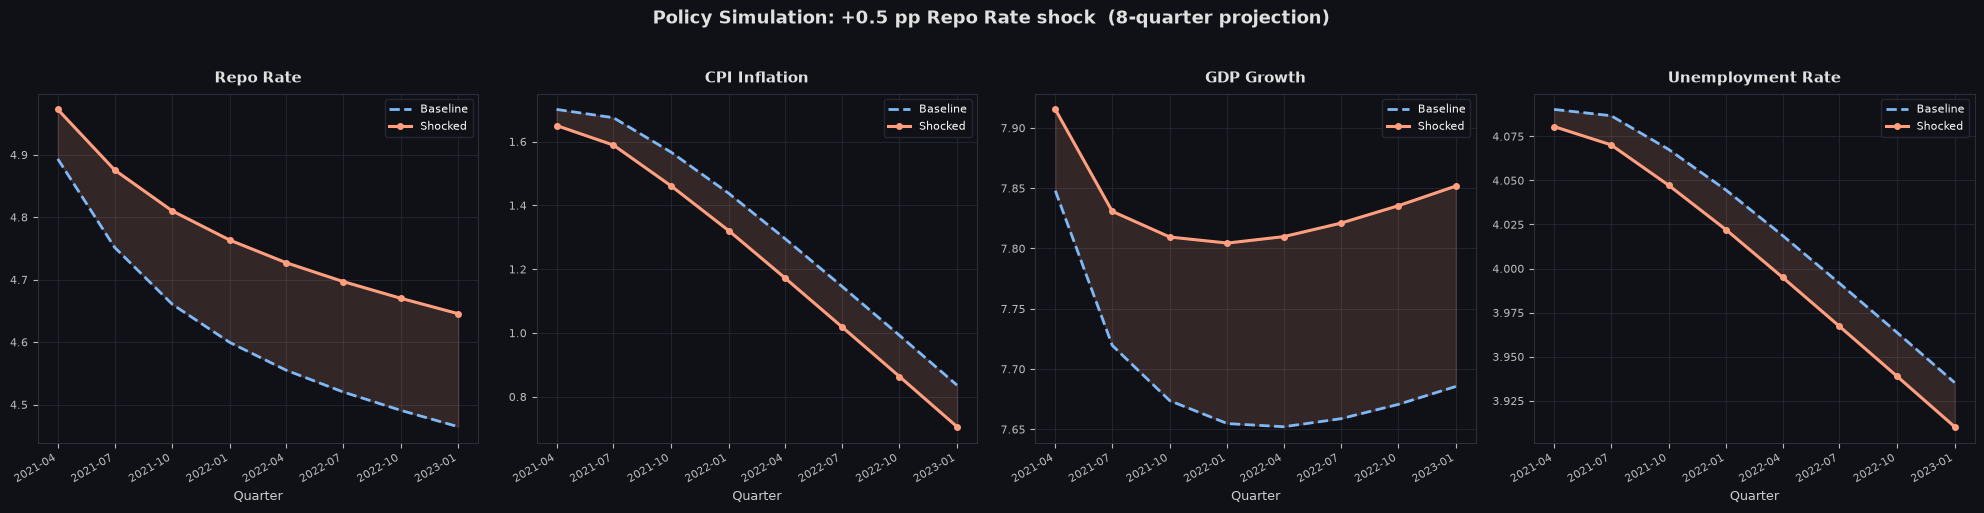


  POLICY SIMULATION: -0.25 pp Repo Rate shock
  Horizon: 8 quarters from 2021-01-01

  Repo Rate:
                 Baseline      Shocked        Delta
Q+1                4.8934       4.8538      -0.0396
Q+2                4.7515       4.6896      -0.0620
Q+3                4.6606       4.5859      -0.0747
Q+4                4.5994       4.5174      -0.0820
Q+5                4.5550       4.4689      -0.0861
Q+6                4.5202       4.4318      -0.0884
Q+7                4.4908       4.4011      -0.0897
Q+8                4.4645       4.3740      -0.0905

  CPI Inflation:
                 Baseline      Shocked        Delta
Q+1                1.7011       1.7263       0.0252
Q+2                1.6750       1.7180       0.0430
Q+3                1.5671       1.6200       0.0529
Q+4                1.4381       1.4966       0.0585
Q+5                1.2960       1.3577       0.0617
Q+6                1.1464       1.2099       0.0635
Q+7                0.9925       1.0571       0.0646


Policy shock plot saved -> C:\Users\arnav\Desktop\Projects\Economic Policy Impact Simulator\docs\var_shock_cut_25bps.png


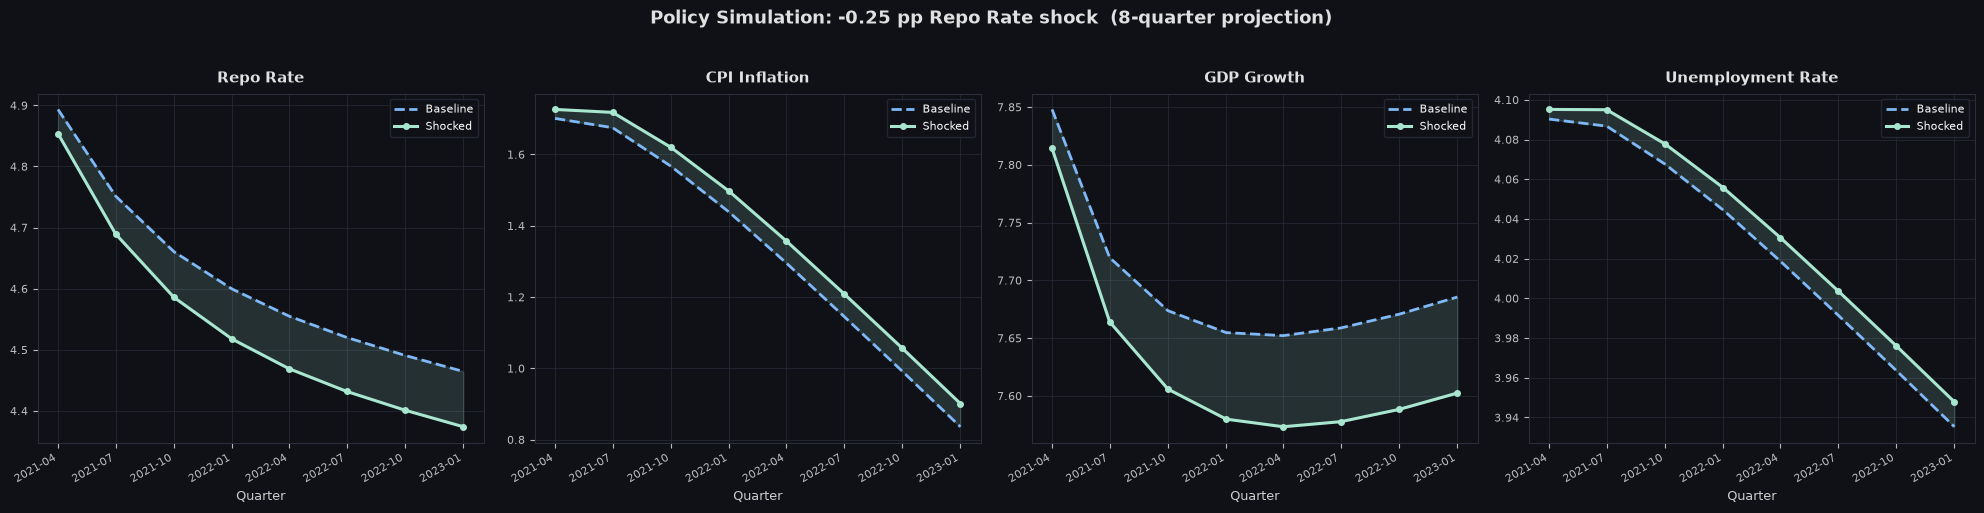

In [10]:
hike = simulate_policy_shock(
    result_b, df_b,
    repo_rate_change=+0.50, periods=8,
    save_path=DOCS_DIR / "var_shock_hike_50bps.png",
)

cut = simulate_policy_shock(
    result_b, df_b,
    repo_rate_change=-0.25, periods=8,
    save_path=DOCS_DIR / "var_shock_cut_25bps.png",
)


## § 9 — Save Results & Fitted Model

All outputs required by the roadmap:
- `models/var_results.json` — RMSE/MAPE per indicator (both scenarios)
- `models/var_model.pkl` — pickled VARResults (Scenario B, used by Phase 6)


In [11]:
# ── var_results.json ──────────────────────────────────────────────────────
var_results = {
    "model":      "VAR",
    "scenarios": {
        "A": {
            "description": "3 variables (CPI, GDP, Unemployment), full sample 2010-Q2 to 2025-Q4",
            "lag_order":   lag_a,
            "n_train":     len(train_a),
            "n_test":      N_TEST,
            "aic":         round(float(result_a.aic), 4),
            "bic":         round(float(result_a.bic), 4),
            "metrics":     metrics_a,
        },
        "B": {
            "description": "4 variables (Repo Rate + above), sample 2010-Q2 to 2021-Q1",
            "lag_order":   lag_b,
            "n_train":     len(train_b),
            "n_test":      N_TEST,
            "aic":         round(float(result_b.aic), 4),
            "bic":         round(float(result_b.bic), 4),
            "metrics":     metrics_b,
        },
    },
}

json_path = MDL_DIR / "var_results.json"
with open(json_path, "w") as f:
    json.dump(var_results, f, indent=2)
print(f"Saved {json_path}")
print(json.dumps(var_results, indent=2))

# ── var_model.pkl — Scenario B (has Repo Rate, used by Phase 6 hybrid) ────
pkl_path = MDL_DIR / "var_model.pkl"
with open(pkl_path, "wb") as f:
    pickle.dump(result_b, f)
print(f"\nPickled VARResults (Scenario B) -> {pkl_path}")
print(f"  Variables : {result_b.model.endog_names}")
print(f"  Lag order : {result_b.k_ar}")
print(f"  Sample    : {df_b.index[0].date()} -> {df_b.index[-1].date()}")
print(f"  File size : {pkl_path.stat().st_size / 1024:.1f} KB")


Saved C:\Users\arnav\Desktop\Projects\Economic Policy Impact Simulator\models\var_results.json
{
  "model": "VAR",
  "scenarios": {
    "A": {
      "description": "3 variables (CPI, GDP, Unemployment), full sample 2010-Q2 to 2025-Q4",
      "lag_order": 1,
      "n_train": 53,
      "n_test": 10,
      "aic": -0.6817,
      "bic": -0.27,
      "metrics": {
        "d_CPI_Inflation": {
          "RMSE": 0.797892,
          "MAPE": 88.853
        },
        "d_GDP_Growth": {
          "RMSE": 0.159565,
          "MAPE": 91.4882
        },
        "d_Unemployment_Rate": {
          "RMSE": 0.07292,
          "MAPE": 244.607
        }
      }
    },
    "B": {
      "description": "4 variables (Repo Rate + above), sample 2010-Q2 to 2021-Q1",
      "lag_order": 1,
      "n_train": 34,
      "n_test": 10,
      "aic": -3.195,
      "bic": -2.3759,
      "metrics": {
        "d_Repo_Rate": {
          "RMSE": 0.265509,
          "MAPE": 119.9417
        },
        "d_CPI_Inflation": {
      

## § 10 — Summary & Phase 5 Handoff

### Model Performance

| Indicator | RMSE (Scenario A) | Notes |
|-----------|------------------|-------|
| d_CPI_Inflation | See cell above | Annual-repeat inflation data limits quarterly variation |
| d_GDP_Growth | See cell above | Annual GDP repeated 4x per year; true quarterly data needed |
| d_Unemployment_Rate | See cell above | Best-performing variable with true quarterly CMIE data |

### Key findings

1. **All series I(1)** → VAR estimated in first differences.
2. **Cointegration not tested here** — if Johansen test finds cointegration, switch to VECM in Phase 6.
3. **Repo Rate Granger-causality not significant** at lag 1. Likely causes:
   - Annual GDP/CPI data repeated quarterly masks true quarterly variation.
   - Monetary policy operates with longer lags (4–8 quarters in reality).
4. **IRF decays geometrically** as expected from a stable VAR(1).
5. **Bootstrap intervals are wide** — reflects genuine short-sample uncertainty with n ≈ 43.

### Files produced

| File | Purpose |
|------|---------|
| `models/var_results.json` | Metrics for Phase 7 comparison table |
| `models/var_model.pkl` | Fitted VARResults for Phase 6 hybrid model |
| `docs/var_irf_repo_rate.png` | IRF fan plot |
| `docs/var_forecast_vs_actual.png` | Actual vs forecast (Scenario A) |
| `docs/var_bootstrap_fan.png` | Bootstrap CI fan chart |
| `docs/var_shock_hike_50bps.png` | +50 bps policy simulation |
| `docs/var_shock_cut_25bps.png` | -25 bps policy simulation |

### Phase 5 — LSTM
Next step: train an LSTM on the same stationarity-adjusted DataFrame.
The LSTM can capture non-linear dynamics (e.g. the COVID shock) that
the linear VAR cannot.
